# 05 · EWMA volatility — a width that reacts when markets turn

## Executive summary (read this first)

**The problem.** The walk measures its sd on the last `window` steps, every step weighted the same. When a calm
period turns turbulent (2020, 2022), that sd catches up slowly, so the bands are too narrow exactly when it
matters. Notebooks 02–04: on validation (2011–16, calmer) the 90 % band was about right; on test (2016–23) it
catches only 84–90 %.

**The change.** The sd becomes an **EWMA** (exponentially weighted moving average) sd: each past step's weight
**halves every `halflife` steps**. Example with `halflife = 21`: yesterday weighs 1, a step one month ago 0.5,
two months ago 0.25. A jump in volatility shows up within days; calm history still counts, a little.

- Only the **sd** changes. The **correlation** between assets stays on the family's window (it needs a stable
  estimate), and the **Student-t** shape (ν) and `widen` stay as in the current model.
- **`halflife`** is the new hyperparameter: 10, 21, 42, 63, 126, 252 steps, or off (the window sd). A step is a
  row of the card's panel (a business day; a month on the 4 monthly cards).

**How it is chosen and judged** — the same protocol, against the **current model** (the Student-t walk of
notebook 04):

1. **train** — for each family, try every `halflife` × `widen` ∈ {0.9 … 1.3}; keep the best pair;
2. **validation** — keep EWMA for a family only if it beats the current model there;
3. **test** — opened once, final model against the current model.

Each card's own score from its `card.toml` (raw, no M0), its three parts, and the share of answers inside the
50 / 90 / 98 % bands. The printed lines in §5–§6 are the result.

## 0 — Setup, data and the current model

In [1]:
import json, multiprocessing as mp, pathlib, subprocess, sys, tempfile, time, tomllib
import numpy as np, pandas as pd
import matplotlib as mpl, matplotlib.pyplot as plt

HERE = pathlib.Path.cwd() if pathlib.Path.cwd().name == "model_baseline" else pathlib.Path.cwd() / "model_baseline"
REPO, DATA, UNITS = HERE.parent, HERE / "data", HERE.parent / "units"
if str(REPO) not in sys.path: sys.path.insert(0, str(REPO))

pd.set_option("display.width", 220); pd.set_option("display.max_columns", 40); pd.set_option("display.max_rows", 150)
INK, INK2, GRID = "#0b0b0b", "#52514e", "#e6e5e1"
FAM = {"T2-F1": "#2a78d6", "T2-F2": "#eb6834", "T2-F3": "#1baf7a", "T2-F4": "#4a3aa7"}
CUR_C, NEW_C = "#8a8983", "#1baf7a"
mpl.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
                     "axes.axisbelow": True, "grid.color": GRID, "axes.edgecolor": INK2,
                     "axes.titlelocation": "left", "legend.frameon": False, "font.size": 10})

TARGETS = pd.read_parquet(DATA / "targets.parquet")
STEPS = pd.read_parquet(DATA / "steps.parquet")
CARDS = {u: tomllib.loads((UNITS / u / "card.toml").read_text()) for u in sorted(TARGETS.unit.unique())}
FAMILY = {u: CARDS[u]["metadata"]["category"] for u in CARDS}
WORKERS = max(1, (mp.cpu_count() or 2) - 2)
geo = lambda r: float(np.exp(np.log(np.asarray(r, float)).mean()))

def parse_t(label):                                  # "130 / 1.1 / ν=4" -> {"window": 130, "widen": 1.1, "nu": 4}
    w, wd, shape = [x.strip() for x in str(label).split("/")]
    return {"window": int(w), "widen": float(wd), "nu": None if shape == "normal" else int(shape.split("=")[1]), "halflife": None}

CURRENT = {u: parse_t(s) for u, s in pd.read_csv(DATA / "t_settings.csv", index_col=0)["final"].items() if u in CARDS}
print("current model (Student-t walk from notebook 04), per family:")
pd.DataFrame({f: CURRENT[next(u for u in CARDS if FAMILY[u] == f)] for f in sorted(FAM)}).T

current model (Student-t walk from notebook 04), per family:


,window,widen,nu,halflife
T2-F1,42.0,1.2,5.0,NaN
T2-F2,130.0,1.1,4.0,NaN
T2-F3,130.0,1.2,4.0,NaN
T2-F4,260.0,1.2,5.0,NaN


## 1 — The model: the walk with an EWMA sd option

`walk_forecast(..., halflife=None)` is exactly the Student-t walk of notebook 04. With a `halflife`, the sd of
each asset is the EWMA sd of its past steps:

```
weight of the step `a` steps ago  =  0.5 ** (a / halflife)
sd  =  √( Σ weight × (step − weighted mean)² / Σ weight )
```

over at most the last `8 × halflife` steps (older weights are below 0.4 %). The correlation still uses the last
`window` steps.

In [2]:
MIN_CHANGES = 10

def ewma_sd(past, halflife):
    """EWMA sd per column of `past` (rows oldest -> newest)."""
    age = np.arange(len(past))[::-1]                                           # 0 = the newest step
    w = 0.5 ** (age / halflife)
    w = w / w.sum()
    mean = w @ past
    return np.sqrt(w @ (past - mean) ** 2)

def walk_forecast(steps, origin, anchor, ksteps, horizons, window=260, widen=1.0, nu=None, halflife=None,
                  n_draws=1000, seed=0):
    """Cumulative random walk with Cholesky; normal or Student-t shocks; window sd or EWMA sd."""
    i = steps.index.searchsorted(pd.Timestamp(origin), side="right")
    arr = steps.to_numpy()
    past = arr[max(0, i - window): i]
    if len(past) < MIN_CHANGES:
        raise ValueError(f"only {len(past)} steps before {origin} (window {window})")
    n_a = past.shape[1]
    D = np.ascontiguousarray(past.T)
    if halflife is None:
        sd = D.std(axis=1) * widen
    else:
        sd = ewma_sd(arr[max(0, i - int(8 * halflife)): i], halflife) * widen
    with np.errstate(invalid="ignore", divide="ignore"):
        corr = np.nan_to_num(np.atleast_2d(np.corrcoef(D)), nan=0.0)
    np.fill_diagonal(corr, 1.0)
    w, v = np.linalg.eigh(corr)
    corr = v @ np.diag(np.clip(w, 1e-8, None)) @ v.T
    L = np.linalg.cholesky(corr)
    rng = np.random.default_rng(seed)
    rng_t = np.random.default_rng([seed, 7])
    out = np.empty((n_draws, n_a, len(horizons)))
    path, prev = np.zeros((n_draws, n_a)), np.zeros(n_a)
    for hi in np.argsort(horizons):
        z = rng.standard_normal((n_draws, n_a)) @ L.T
        rng.standard_normal((n_draws, n_a))                                    # production's skew draw (unused)
        if nu is not None:
            z = z * np.sqrt((nu - 2.0) / rng_t.chisquare(nu, size=(n_draws, 1)))
        kk = np.asarray(ksteps, float)[:, hi]
        path = path + z * sd * np.sqrt(np.maximum(kk - prev, 0))
        prev = kk
        out[:, :, hi] = np.asarray(anchor, float) + path
    return out

from qfbench2_track_forecasting import scoring as S

def card_score(card, samples, y):
    p = card.get("scoring", {}).get("params", {})
    w = p.get("weights", {"marginal": 0.5, "joint": 0.3, "tail": 0.2})
    w = (float(w["marginal"]), float(w["joint"]), float(w["tail"]))
    if samples.shape[1] == 1:
        live = w[0] + w[2]; w = (w[0] / live, 0.0, w[2] / live)
    out = S._composite(samples, y, weights=w, tail_levels=tuple(p.get("tail_levels", (0.01, 0.05, 0.95, 0.99))),
                       joint=S.card_joint_statistic(card), tail_metric=str(p.get("tail_metric", S.DEFAULT_TAIL_METRIC)),
                       ref_scale=None)
    q = np.quantile(samples, [0.01, 0.05, 0.25, 0.75, 0.95, 0.99], axis=0)
    inside = lambda lo, hi: float(np.mean((y >= q[lo]) & (y <= q[hi])))
    return {**out, "cov50": inside(2, 3), "cov90": inside(1, 4), "cov98": inside(0, 5)}

def card_inputs(u):
    card = CARDS[u]; t = card["targets"]
    assets, horizons = [str(a) for a in t["asset_ids"]], [int(h) for h in t["horizons"]]
    steps = STEPS[STEPS.unit == u].pivot(index="date", columns="asset", values="step")[assets].sort_index()
    tt = TARGETS[TARGETS.unit == u].set_index(["origin_date", "asset", "horizon"]).sort_index()
    return card, assets, horizons, steps, tt

def at_origin(tt, origin, assets, horizons):
    r = tt.loc[origin]
    anchor = np.array([r.loc[(a, horizons[0]), "anchor"] for a in assets])
    ksteps = np.array([[r.loc[(a, h), "steps"] for h in horizons] for a in assets])
    y = np.array([r.loc[(a, h), "target"] for a in assets for h in horizons])
    return anchor, ksteps, y

**How fast each sd reacts.** The US 10-year yield (`t2-F3-boj-ust-channel-2023`) through 2019–2023: the daily
sd the model would use at each date, window-260 against EWMA. Around March 2020 the EWMA sd jumps within days;
the window sd needs months, and then stays high long after the calm returns.

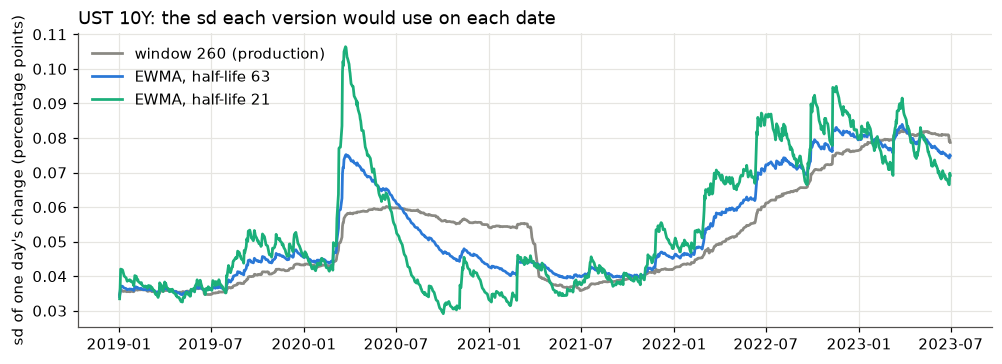

In [3]:
card, assets, horizons, steps, tt = card_inputs("t2-F3-boj-ust-channel-2023")
s = steps["UST_10Y"]; dates = s.loc["2019-01-01":"2023-06-30"].index
arr = steps[["UST_10Y"]].to_numpy()
def sd_path(fn):
    out = []
    for d in dates:
        i = steps.index.searchsorted(d, side="right"); out.append(fn(i))
    return np.array(out)
paths = {"window 260 (production)": sd_path(lambda i: arr[max(0, i - 260): i, 0].std()),
         "EWMA, half-life 63": sd_path(lambda i: ewma_sd(arr[max(0, i - 504): i], 63)[0]),
         "EWMA, half-life 21": sd_path(lambda i: ewma_sd(arr[max(0, i - 168): i], 21)[0])}
fig, ax = plt.subplots(figsize=(9, 3.2), layout="constrained")
for (name, v), col in zip(paths.items(), [CUR_C, "#2a78d6", NEW_C]):
    ax.plot(dates, v, color=col, lw=1.8, label=name)
ax.set_ylabel("sd of one day's change (percentage points)"); ax.legend(loc="upper left")
ax.set_title("UST 10Y: the sd each version would use on each date"); plt.show()

## 2 — Checks

1. With `halflife=None`, `nu=None` and production's settings (260 / 1.0) the draws equal production's walk exactly.
2. `ewma_sd` against pandas' own exponentially weighted sd on the same numbers.
3. With EWMA, `card_score` still equals the official scorer's number.

In [4]:
import forecast_agent as fa, forecast_models as fm
u = "t2-F3-boj-ust-channel-2023"
card, assets, horizons, steps, tt = card_inputs(u); t = card["targets"]
o = np.sort(tt[tt.split == "test"].index.get_level_values(0).unique())[100]
anchor, ksteps, y = at_origin(tt, o, assets, horizons)
mine = walk_forecast(steps, o, anchor, ksteps, horizons, window=260, widen=1.0, nu=None, halflife=None, seed=3)
req = fm._Request(fa._read_panels(UNITS / u), assets, horizons, str(pd.Timestamp(o).date()), {a: {} for a in assets},
                  1000, 3, t["target_type"], None)   # family None: production's plain walk (260 / 1.0 / normal)
diff = float(np.abs(mine - fm._cumulative_walk_model(req)).max())
print("1. walk_forecast vs production, max |difference|:", diff); assert diff == 0

x = steps.loc[:o].iloc[-400:].to_numpy()
ref = pd.DataFrame(x).ewm(halflife=42, adjust=True).std(bias=True).iloc[-1].to_numpy()
print("2. ewma_sd", ewma_sd(x, 42).round(6), " pandas ewm(halflife=42).std(bias=True)", ref.round(6))
assert np.allclose(ewma_sd(x, 42), ref, rtol=1e-6)

d3 = walk_forecast(steps, o, anchor, ksteps, horizons, window=130, widen=1.1, nu=4, halflife=21)
with tempfile.TemporaryDirectory() as tmp:
    out_dir, real = pathlib.Path(tmp) / "out", pathlib.Path(tmp) / "realized.parquet"; out_dir.mkdir()
    pd.DataFrame([{"draw": np.int32(d), "asset": a, "horizon": np.int32(h), "value": float(d3[d, ai, hi])}
                  for d in range(len(d3)) for ai, a in enumerate(assets) for hi, h in enumerate(horizons)]).to_parquet(out_dir / "forecast.parquet", index=False)
    (out_dir / "forecast_meta.json").write_text(json.dumps({"unit_id": card["task"]["id"], "asof": card["provenance"]["data_cutoff"],
        "representation": "samples", "asset_ids": assets, "horizons": horizons, "n_draws": len(d3), "target": t["target_type"]}))
    (out_dir / "forecast_rationale.md").write_text("# check\n")
    pd.DataFrame([{"asset": a, "horizon": h, "value": float(v)} for (a, h), v in zip([(a, h) for a in assets for h in horizons], y)]).to_parquet(real, index=False)
    r = subprocess.run([sys.executable, str(REPO / "scoring" / "scoring.py"), "score", "--card", str(UNITS / u / "card.toml"),
                        "--forecast", str(out_dir / "forecast.parquet"), "--realized", str(real)], capture_output=True, text=True, cwd=REPO)
official, mine_s = json.loads(r.stdout)["composite_score"], card_score(card, d3.reshape(len(d3), -1), y)["composite"]
print(f"3. EWMA t-walk score {mine_s:.10f}  official scorer {official:.10f}  equal: {np.isclose(mine_s, official, rtol=0, atol=1e-12)}")
assert np.isclose(mine_s, official, rtol=0, atol=1e-12)

1. walk_forecast vs production, max |difference|: 0.0
2. ewma_sd [0.043603 0.873617]  pandas ewm(halflife=42).std(bias=True) [0.043603 0.873617]


3. EWMA t-walk score 3.0034871370  official scorer 3.0034871370  equal: True


## 3 — The runner (same design as notebooks 02 and 04)

In [5]:
def key(s):
    shape = "normal" if s["nu"] is None else f'ν={int(s["nu"])}'
    vol = "window sd" if s["halflife"] is None else f'EWMA hl={int(s["halflife"])}'
    return f'{int(s["window"])} / {float(s["widen"]):.1f} / {shape} / {vol}'

def score_card(args):
    u, block, settings, stride, n_draws, keep_pit = args
    card, assets, horizons, steps, tt = card_inputs(u)
    sub = tt[tt.split == block]
    cells = [(a, h) for a in assets for h in horizons]
    rows, pits = [], []
    for j, o in enumerate(np.sort(sub.index.get_level_values(0).unique())[::stride]):
        anchor, ksteps, y = at_origin(sub, o, assets, horizons)
        try:
            draws = [walk_forecast(steps, o, anchor, ksteps, horizons, n_draws=n_draws, seed=j, **s).reshape(n_draws, -1)
                     for s in settings]
        except ValueError:
            continue
        for s, d in zip(settings, draws):
            rows.append({"unit": u, "family": FAMILY[u], "block": block, "origin": o, "setting": key(s), **card_score(card, d, y)})
            if keep_pit:
                pits += [{"unit": u, "family": FAMILY[u], "origin": o, "setting": key(s), "asset": a, "horizon": h, "pit": float(p)}
                         for (a, h), p in zip(cells, (d < y).mean(axis=0))]
    return rows, pits

def run(jobs):
    with mp.get_context("fork").Pool(WORKERS) as pool:
        out = pool.map(score_card, jobs, chunksize=1)
    return pd.DataFrame([r for rows, _ in out for r in rows]), pd.DataFrame([p for _, ps in out for p in ps])

## 4 — Tune `halflife` and `widen` on train, per family

Each card keeps its family's window and ν; every 21st train date, 500 draws. A pair's quality in a family =
geometric mean over its cards of (pair's mean score ÷ the current model's mean score).

In [6]:
HALFLIVES, WIDENS = [10, 21, 42, 63, 126, 252, None], [0.9, 1.0, 1.1, 1.2, 1.3]

def grid_for(u):
    c = CURRENT[u]
    g = [{**c, "widen": wd, "halflife": hl} for hl in HALFLIVES for wd in WIDENS]
    return g + ([c] if c not in g else [])

t0 = time.time()
tr, _ = run([(u, "train", grid_for(u), 21, 500, False) for u in CARDS])
print(f"train: {tr.groupby('unit').origin.nunique().sum():,} dates, {len(tr):,} forecasts, {time.time() - t0:.0f}s")

m = tr.groupby(["unit", "family", "setting"]).composite.mean().rename("score").reset_index()
base = {u: m[(m.unit == u) & (m.setting == key(CURRENT[u]))].score.iloc[0] for u in m.unit.unique()}
m["ratio"] = m.score / m.unit.map(base)
parts = m.setting.str.split(" / ", expand=True); m["widen"] = parts[1].astype(float); m["vol"] = parts[3]
order = [f"EWMA hl={h}" for h in HALFLIVES if h is not None] + ["window sd"]
grid = m.groupby(["family", "vol", "widen"]).ratio.apply(geo).unstack("widen")
for f in sorted(FAM):
    print(f"\n{f}: train score ÷ current model (rows: sd, columns: widen)")
    display(grid.loc[f].reindex(order).round(3))
CHOSEN = {f: m[m.family == f].groupby("setting").ratio.apply(geo).idxmin() for f in sorted(FAM)}
print("chosen on train:", CHOSEN)

train: 8,671 dates, 303,485 forecasts, 12s

T2-F1: train score ÷ current model (rows: sd, columns: widen)


widen,0.9,1.0,1.1,1.2,1.3
vol,,,,,
EWMA hl=10,1.039,1.020,1.009,1.002,1.000
EWMA hl=21,1.032,1.015,1.004,0.999,0.998
EWMA hl=42,1.030,1.014,1.004,1.000,1.000
EWMA hl=63,1.030,1.014,1.005,1.002,1.003
EWMA hl=126,1.030,1.016,1.007,1.005,1.007
EWMA hl=252,1.030,1.016,1.008,1.006,1.009
window sd,1.034,1.017,1.006,1.000,0.999



T2-F2: train score ÷ current model (rows: sd, columns: widen)


widen,0.9,1.0,1.1,1.2,1.3
vol,,,,,
EWMA hl=10,1.026,1.018,1.014,1.013,1.015
EWMA hl=21,1.017,1.010,1.006,1.007,1.011
EWMA hl=42,1.013,1.006,1.004,1.005,1.009
EWMA hl=63,1.012,1.006,1.004,1.005,1.010
EWMA hl=126,1.012,1.007,1.005,1.007,1.012
EWMA hl=252,1.014,1.008,1.006,1.008,1.014
window sd,1.009,1.002,1.000,1.001,1.005



T2-F3: train score ÷ current model (rows: sd, columns: widen)


widen,0.9,1.0,1.1,1.2,1.3
vol,,,,,
EWMA hl=10,1.059,1.037,1.023,1.018,1.018
EWMA hl=21,1.045,1.024,1.011,1.006,1.008
EWMA hl=42,1.035,1.014,1.003,0.998,1.001
EWMA hl=63,1.031,1.011,1.000,0.996,1.000
EWMA hl=126,1.029,1.010,1.000,0.998,1.002
EWMA hl=252,1.029,1.012,1.003,1.003,1.009
window sd,1.036,1.016,1.004,1.000,1.003



T2-F4: train score ÷ current model (rows: sd, columns: widen)


widen,0.9,1.0,1.1,1.2,1.3
vol,,,,,
EWMA hl=10,1.032,1.018,1.009,1.005,1.004
EWMA hl=21,1.026,1.013,1.005,1.002,1.003
EWMA hl=42,1.021,1.009,1.002,0.999,1.001
EWMA hl=63,1.019,1.007,1.001,0.999,1.001
EWMA hl=126,1.018,1.007,1.002,1.001,1.003
EWMA hl=252,1.020,1.010,1.005,1.005,1.008
window sd,1.019,1.007,1.002,1.000,1.002


chosen on train: {'T2-F1': '42 / 1.3 / ν=5 / EWMA hl=21', 'T2-F2': '130 / 1.1 / ν=4 / window sd', 'T2-F3': '130 / 1.2 / ν=4 / EWMA hl=63', 'T2-F4': '260 / 1.2 / ν=5 / EWMA hl=63'}


## 5 — Validation: keep EWMA for a family only if it beats the current model there

In [7]:
def setting_of(label):
    w, wd, shape, vol = [x.strip() for x in label.split("/")]
    return {"window": int(w), "widen": float(wd), "nu": None if shape == "normal" else int(shape.split("=")[1]),
            "halflife": None if vol == "window sd" else int(vol.split("=")[1])}

CANDIDATE = {u: setting_of(CHOSEN[FAMILY[u]]) for u in CARDS}

def compare(block, model_a, model_b, keep_pit=False):
    jobs = [(u, block, [model_a[u]] + ([model_b[u]] if model_b[u] != model_a[u] else []), 5, 1000, keep_pit) for u in CARDS]
    sc, pit = run(jobs)
    cm = sc.groupby(["unit", "setting"])[["composite", "marginal", "joint", "tail", "cov50", "cov90", "cov98"]].mean()
    rows = []
    for u in sorted(set(sc.unit)):
        a, b = cm.loc[(u, key(model_a[u]))], cm.loc[(u, key(model_b[u]))]
        rows.append({"unit": u, "family": FAMILY[u], "ratio": a.composite / b.composite,
                     **{f"{c}_ratio": (a[c] / b[c] if b[c] > 0 else np.nan) for c in ("marginal", "joint", "tail")},
                     **{f"{c}_{n}": x[c] for n, x in (("new", a), ("current", b)) for c in ("cov50", "cov90", "cov98")},
                     "score_new": a.composite, "score_current": b.composite})
    return sc, pit, pd.DataFrame(rows)

t0 = time.time()
va, _, va_res = compare("validation", CANDIDATE, CURRENT)
print(f"validation: {va.groupby('unit').origin.nunique().sum():,} dates, {time.time() - t0:.0f}s")
va_fam = va_res.groupby("family").agg(ratio=("ratio", geo), cards_better=("ratio", lambda r: f"{(r < 1).sum()}/{len(r)}"),
                                      inside_90_current=("cov90_current", "mean"), inside_90_new=("cov90_new", "mean"),
                                      inside_98_current=("cov98_current", "mean"), inside_98_new=("cov98_new", "mean"))
display(va_fam.round(3))
FINAL = {u: (CANDIDATE[u] if va_fam.loc[FAMILY[u], "ratio"] < 1.0 else CURRENT[u]) for u in CARDS}
for f in sorted(FAM):
    print(f"{f}: " + (f"use EWMA  {CHOSEN[f]}" if va_fam.loc[f, "ratio"] < 1.0 else "keep the current model (EWMA did not beat it on validation)"))

validation: 16,484 dates, 3s


,ratio,cards_better,inside_90_current,inside_90_new,inside_98_current,inside_98_new
family,,,,,,
T2-F1,1.011,10/23,0.899,0.937,0.983,0.988
T2-F2,1.000,0/27,0.882,0.882,0.973,0.973
T2-F3,1.001,10/22,0.907,0.915,0.976,0.980
T2-F4,0.991,28/31,0.942,0.947,0.993,0.994


T2-F1: keep the current model (EWMA did not beat it on validation)
T2-F2: keep the current model (EWMA did not beat it on validation)
T2-F3: keep the current model (EWMA did not beat it on validation)
T2-F4: use EWMA  260 / 1.2 / ν=5 / EWMA hl=63


## 6 — The hidden test set, opened once: the final model against the current model

**ratio < 1: the final model is better on that card's test dates.**

In [8]:
t0 = time.time()
te, te_pit, te_res = compare("test", FINAL, CURRENT, keep_pit=True)
print(f"test: {te.groupby('unit').origin.nunique().sum():,} dates, {time.time() - t0:.0f}s")
def fam_table(res):
    rows = {}
    for name, d in [*res.groupby("family"), ("all", res)]:
        rows[name] = {"cards": len(d), "score ratio": geo(d.ratio), "cards better": f"{(d.ratio < 1).sum()}/{len(d)}",
                      "marginal ratio": geo(d.marginal_ratio), "tail ratio": geo(d.tail_ratio),
                      "joint ratio": geo(d.joint_ratio.dropna()) if d.joint_ratio.notna().any() else np.nan,
                      **{f"inside_{b} current → final": f"{d[f'cov{b}_current'].mean():.3f} → {d[f'cov{b}_new'].mean():.3f}" for b in (50, 90, 98)}}
    return pd.DataFrame(rows).T
display(fam_table(te_res))
r_all = geo(te_res.ratio)
print(f"ON TEST the final model scores {r_all:.3f} x the current model, better on {(te_res.ratio < 1).sum()}/{len(te_res)} cards: "
      + ("better." if r_all < 0.99 else "no real difference (within 1%)." if r_all < 1.01 else "worse."))

test: 24,252 dates, 3s


,cards,score ratio,cards better,marginal ratio,tail ratio,joint ratio,inside_50 current → final,inside_90 current → final,inside_98 current → final
T2-F1,23,1.0,0/23,1.0,1.0,1.0,0.513 → 0.513,0.841 → 0.841,0.935 → 0.935
T2-F2,27,1.0,0/27,1.0,1.0,1.0,0.461 → 0.461,0.847 → 0.847,0.954 → 0.954
T2-F3,22,1.0,0/22,1.0,1.0,1.0,0.508 → 0.508,0.896 → 0.896,0.975 → 0.975
T2-F4,31,0.993843,26/31,0.994921,0.974286,0.999685,0.491 → 0.493,0.904 → 0.908,0.978 → 0.980
all,103,0.998143,26/103,0.998469,0.99219,0.999985,0.492 → 0.492,0.873 → 0.875,0.961 → 0.962


ON TEST the final model scores 0.998 x the current model, better on 26/103 cards: no real difference (within 1%).


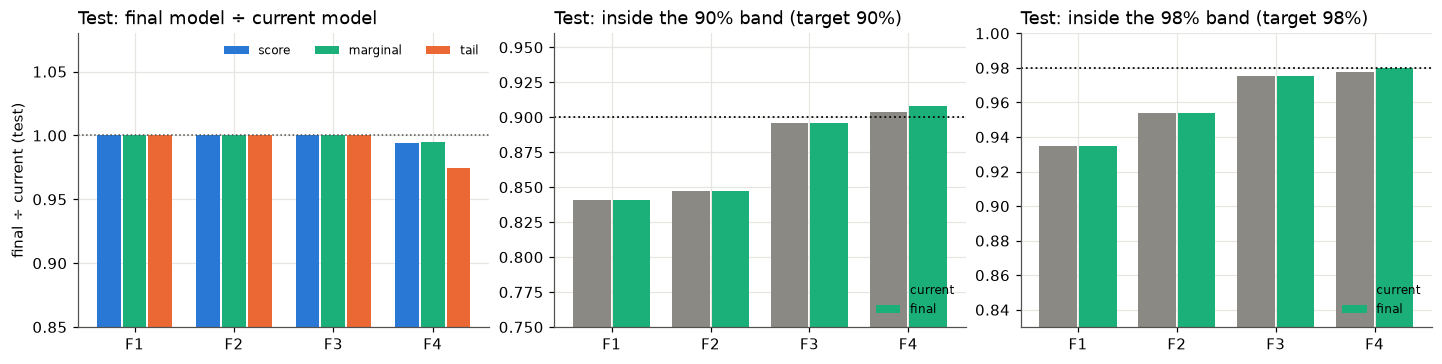

In [9]:
fams = sorted(FAM)
fig, axes = plt.subplots(1, 3, figsize=(13, 3.2), layout="constrained")
x = np.arange(len(fams))
for j, (col, lab) in enumerate((("ratio", "score"), ("marginal_ratio", "marginal"), ("tail_ratio", "tail"))):
    axes[0].bar(x + (j - 1) * 0.26, [geo(te_res.loc[te_res.family == f, col]) for f in fams], width=0.24,
                color=["#2a78d6", "#1baf7a", "#eb6834"][j], label=lab)
axes[0].axhline(1, color=INK2, ls=":", lw=1); axes[0].set_xticks(x, [f[3:] for f in fams]); axes[0].set_ylim(0.85, 1.08)
axes[0].set_ylabel("final ÷ current (test)"); axes[0].set_title("Test: final model ÷ current model"); axes[0].legend(fontsize=8, ncols=3)
for ax, b, tgt in ((axes[1], 90, 0.9), (axes[2], 98, 0.98)):
    ax.bar(x - 0.2, [te_res.loc[te_res.family == f, f"cov{b}_current"].mean() for f in fams], width=0.38, color=CUR_C, label="current")
    ax.bar(x + 0.2, [te_res.loc[te_res.family == f, f"cov{b}_new"].mean() for f in fams], width=0.38, color=NEW_C, label="final")
    ax.axhline(tgt, color=INK, ls=":", lw=1.2); ax.set_xticks(x, [f[3:] for f in fams])
    ax.set_ylim(tgt - 0.15, min(1.0, tgt + 0.06)); ax.set_title(f"Test: inside the {b}% band (target {b}%)"); ax.legend(fontsize=8, loc="lower right")
plt.show()

**PIT on test** — current model against the final model. Flat = calibrated.

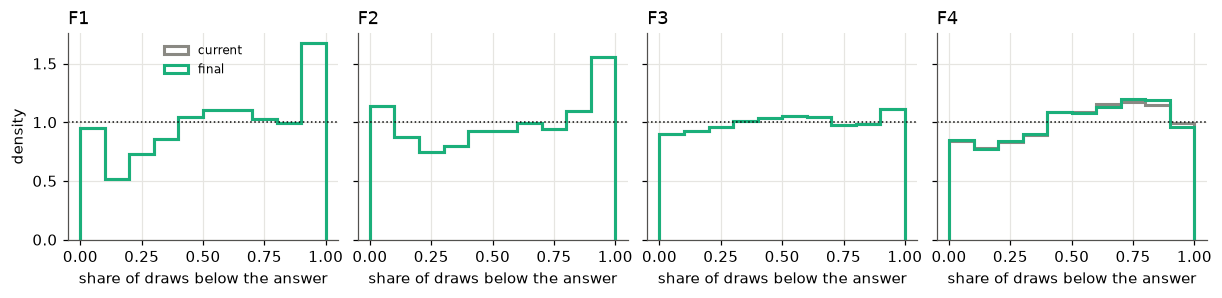

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(11, 2.6), layout="constrained", sharey=True)
bins = np.linspace(0, 1, 11)
for ax, f in zip(axes, fams):
    for model, col, lab in ((CURRENT, CUR_C, "current"), (FINAL, NEW_C, "final")):
        mine = pd.Series([key(model[u]) for u in te_pit.unit], index=te_pit.index)
        v = te_pit.loc[(te_pit.family == f) & (te_pit.setting == mine), "pit"]
        ax.hist(v, bins=bins, density=True, histtype="step", lw=2, color=col, label=lab)
    ax.axhline(1, color=INK, lw=1, ls=":"); ax.set_title(f[3:]); ax.set_xlabel("share of draws below the answer")
axes[0].set_ylabel("density"); axes[0].legend(fontsize=8, loc="upper center"); plt.show()

## 7 — Every card on test

In [11]:
card_tab = te_res.set_index(["family", "unit"])[["score_current", "score_new", "ratio", "marginal_ratio", "tail_ratio",
                                                   "cov90_current", "cov90_new", "cov98_current", "cov98_new"]]
card_tab.insert(0, "final setting", [key(FINAL[u]) for u in card_tab.index.get_level_values("unit")])
card_tab.style.format({c: "{:.3f}" for c in card_tab.columns if c not in ("final setting", "score_current", "score_new")}
                      | {"score_current": "{:.4g}", "score_new": "{:.4g}"}).background_gradient(subset=["ratio"], cmap="RdYlGn_r", vmin=0.9, vmax=1.1)

## 8 — Save

In [12]:
pd.DataFrame({"family": FAMILY, "current": {u: key(CURRENT[u]) for u in CARDS}, "final": {u: key(FINAL[u]) for u in CARDS}}
             ).to_csv(DATA / "ewma_settings.csv")
tr.to_parquet(DATA / "ewma_tune_train.parquet", index=False)
va.to_parquet(DATA / "ewma_validation.parquet", index=False)
te.to_parquet(DATA / "ewma_test.parquet", index=False)
te_res.to_csv(DATA / "ewma_test_per_unit.csv", index=False)
for f in ("ewma_settings.csv", "ewma_tune_train.parquet", "ewma_validation.parquet", "ewma_test.parquet", "ewma_test_per_unit.csv"):
    print(f"data/{f:<26} {(DATA / f).stat().st_size / 1e6:6.2f} MB")

data/ewma_settings.csv            0.01 MB
data/ewma_tune_train.parquet      8.67 MB
data/ewma_validation.parquet      1.08 MB
data/ewma_test.parquet            1.14 MB
data/ewma_test_per_unit.csv       0.02 MB
